# Promoter Generation & AlphaGenome Evaluation

1. **Part 1-3**: Gene 이름 입력 → TSS upstream 서열 가져오기 → Iterative MLM으로 promoter 생성 → CSV 저장
2. **Part 4**: 저장된 CSV 로드 → AlphaGenome `predict_variants`로 활성 비교 (특정 ontology terms)
3. **Part 5**: 전체 ontology term scan → 어느 cell type에서 가장 높은 활성을 보이는지 확인

In [1]:
# %%capture
# Colab setup
# !git clone https://github.com/leemnj/iterative-dna-reconstruction.git
# %cd iterative-dna-reconstruction/03_dna-fm-to-alphagenome/regulator-to-alphagenome
%pip -q install biopython alphagenome python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import sys
from pathlib import Path

import pandas as pd
import torch

# ── Path setup ───────────────────────────────────────────────────
# utils.py (03_dna-fm-to-alphagenome/)
sys.path.append(str(Path('..').resolve()))
# idr package (01_generate-seq-and-emb/src/)
sys.path.append(str((Path('../..') / '01_generate-seq-and-emb' / 'src').resolve()))

# ── Gene & Promoter Settings ─────────────────────────────────────
GENE_NAME = 'GAPDH'
PROMOTER_TSS_LENGTH = 300        # -250 ~ +50 bp from TSS

# ── Iterative MLM Settings ───────────────────────────────────────
ITERATIONS = 20
MASK_RATIO = 0.1
DECODING_STRATEGY = 'sampling'   # 'greedy', 'sampling', 'top_k'
TEMPERATURE = 1.0
TOP_K = 50
TORCH_DTYPE = 'float32'

MODEL_CONFIGS = {
    'DNABERT-2': 'zhihan1996/DNABERT-2-117M',
    'NT-v2-50m': 'InstaDeepAI/nucleotide-transformer-v2-50m-multi-species',
    'NT-v2-500m': 'InstaDeepAI/nucleotide-transformer-v2-500m-multi-species',
    'NT-v3-650m-pre': 'InstaDeepAI/NTv3_650M_pre',
    'NT-v3-650m-post': 'InstaDeepAI/NTv3_650M_post',
}

# ── AlphaGenome Evaluation Settings ──────────────────────────────
REQUESTED_OUTPUT_TYPES = {'CAGE', 'PROCAP', 'RNA_SEQ'}  # 수정 가능
ONTOLOGY_TERMS = ['EFO:0002067', 'CL:0000765']          # None = 모든 ontology
EVAL_ITERATIONS = [0, 5, 10, 15, 20]                     # 평가할 iteration 목록
PROMOTER_PADDING = 500                                    # Part 5 분석용 padding (bp)

# ── Data Paths ───────────────────────────────────────────────────
DATA_DIR = Path('../../data')
PROMOTER_DIR = (
    DATA_DIR / 'promoters'
    / f'{DECODING_STRATEGY}_t{TEMPERATURE}_mask{MASK_RATIO}_iter{ITERATIONS}'
)
PROMOTER_DIR.mkdir(parents=True, exist_ok=True)

ENSEMBL_SPECIES = 'human'
ENSEMBL_ASSEMBLY = 'GRCh38'

MODEL_LABELS = list(MODEL_CONFIGS.keys())

print(f'Gene: {GENE_NAME}')
print(f'Promoter length: {PROMOTER_TSS_LENGTH} bp')
print(f'Strategy: {DECODING_STRATEGY}, T={TEMPERATURE}, top_k={TOP_K}')
print(f'Iterations: {ITERATIONS}, Mask ratio: {MASK_RATIO}')
print(f'Models: {MODEL_LABELS}')
print(f'Output dir: {PROMOTER_DIR}')

Gene: GAPDH
Promoter length: 300 bp
Strategy: sampling, T=1.0, top_k=50
Iterations: 20, Mask ratio: 0.1
Models: ['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m', 'NT-v3-650m-pre', 'NT-v3-650m-post']
Output dir: ../../data/promoters/sampling_t1.0_mask0.1_iter20


## Part 2: Gene Lookup & Sequence Fetch

In [3]:
from utils import (
    load_gtf_feather,
    get_sequence_from_ensembl_region,
    normalize_sequence,
)

gtf = load_gtf_feather(data_dir=DATA_DIR)

# Find gene in GTF
gene_gtf = gtf[
    (gtf['gene_name'] == GENE_NAME) & (gtf['transcript_support_level'] == '1')
].iloc[0]

chrom = gene_gtf['Chromosome']
strand = gene_gtf['Strand']
gene_start = int(gene_gtf['Start'])
gene_end = int(gene_gtf['End'])
gene_id = gene_gtf['gene_id']

print(f'{GENE_NAME} ({gene_id}): {chrom}:{gene_start}-{gene_end} ({strand})')

gencode.v46.annotation.gtf.gz.feather already exists!
GAPDH (ENSG00000111640.15): chr12:6534516-6538371 (+)


In [4]:
# Calculate TSS and promoter region
if strand == '+':
    tss = gene_start + 50
    promoter_start = tss - PROMOTER_TSS_LENGTH
    promoter_end = tss
else:
    tss = gene_end - 50
    promoter_start = tss
    promoter_end = tss + PROMOTER_TSS_LENGTH

print(f'TSS: {chrom}:{tss} ({strand})')
print(f'Promoter region (hg38): {chrom}:{promoter_start}-{promoter_end}')

# Fetch from Ensembl
promoter_seq_raw = get_sequence_from_ensembl_region(
    ENSEMBL_SPECIES, chrom, promoter_start, promoter_end,
    strand, coord_system_version=ENSEMBL_ASSEMBLY,
)
promoter_seq = normalize_sequence(promoter_seq_raw)

print(f'Promoter sequence length: {len(promoter_seq)}')
print(f'{promoter_seq[:50]}...{promoter_seq[-50:]}')

TSS: chr12:6534566 (+)
Promoter region (hg38): chr12:6534266-6534566
Promoter sequence length: 300
CAATCTCAGTCCCTTCCCCCCTACGTCGGGGCCCACACGCTCGGTGCGTG...CGCTCTCTGCTCCTCCTGTTCGACAGTCAGCCGCATCTTCTTTTGCGTCG


## Part 3: Iterative MLM Sequence Generation
각 모델로 iterative masked language modeling을 수행하여 promoter 서열을 생성합니다.

In [5]:
from idr.utils import get_device, iter_models

device = get_device()
print(f'Device: {device}')

for model_label, model_instance in iter_models(
    device, MODEL_CONFIGS, torch_dtype=TORCH_DTYPE
):
    print(f'\n=== {model_label} ===')

    model_dir = PROMOTER_DIR / model_label
    model_dir.mkdir(parents=True, exist_ok=True)
    output_csv = model_dir / f'{GENE_NAME}_promoter.csv'

    # Run iterative MLM
    generated_sequences = model_instance.run(
        sequence=promoter_seq,
        steps=ITERATIONS,
        mask_ratio=MASK_RATIO,
        strategy=DECODING_STRATEGY,
        temperature=TEMPERATURE,
        top_k=TOP_K,
        save_all=True,
        save_interval=1,
    )

    strategy_key = (
        DECODING_STRATEGY if DECODING_STRATEGY == 'greedy'
        else f'{DECODING_STRATEGY}_t{TEMPERATURE}'
    )
    results_data = {strategy_key: generated_sequences}

    df = pd.DataFrame(results_data).T
    df.columns = [f'iter_{i:02d}' for i in range(df.shape[1])]
    df.to_csv(output_csv)
    print(f'Saved: {output_csv}')

    # Length check (DNABERT-2 may produce shorter sequences)
    final_len = len(generated_sequences[-1])
    if final_len != len(promoter_seq):
        print(f'  ⚠️ Length changed: {len(promoter_seq)} → {final_len}')

    del generated_sequences, model_instance
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()
    elif device == 'mps':
        torch.mps.empty_cache()

print('\n=== All models done ===')

PyTorch Version: 2.9.1
Using device: mps
Device: mps
📥 Downloading DNABERT-2...


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

✅ DNABERT-2 Triton patch applied successfully.
[DNABERT-2] Loading model...


/Users/leeminjae/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


[DNABERT-2] Model loaded successfully.
✅ DNABERT-2 loaded successfully.

=== DNABERT-2 ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/DNABERT-2/GAPDH_promoter.csv
  ⚠️ Length changed: 300 → 304
[NT-v2-50m] Loading model...
[NT-v2-50m] Model loaded successfully.
✅ NT-v2-50m loaded successfully.

=== NT-v2-50m ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/NT-v2-50m/GAPDH_promoter.csv
[NT-v2-500m] Loading model...
[NT-v2-500m] Model loaded successfully.
✅ NT-v2-500m loaded successfully.

=== NT-v2-500m ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/NT-v2-500m/GAPDH_promoter.csv
[NT-v3-650m-pre] Loading model...
[NT-v3-650m-pre] Model loaded successfully.
✅ NT-v3-650m-pre loaded successfully.

=== NT-v3-650m-pre ===
Saved: ../../data/promoters/sampling_t1.0_mask0.1_iter20/NT-v3-650m-pre/GAPDH_promoter.csv
[NT-v3-650m-post] Loading model...
[NT-v3-650m-post] AutoModelForMaskedLM load failed, using AutoModel fallback: Unrecognized configuration clas

---
## Part 4: AlphaGenome Evaluation — Specific Ontology Terms
저장된 CSV를 로드하여 AlphaGenome으로 활성 변화를 평가합니다.

**이 섹션부터는 Part 3과 독립적으로 실행 가능합니다** (CSV만 있으면 됨).

In [6]:
import copy

from utils import (
    get_dna_model,
    get_output_metadata,
    load_gtf_feather,
    prepare_gtf_views,
    build_transcript_extractors,
    get_sequence_from_ensembl_region,
    normalize_sequence,
    reverse_complement,
)

# ── Load generated promoter CSVs ─────────────────────────────────
promoter_dfs = {}
for model in MODEL_LABELS:
    csv_path = PROMOTER_DIR / model / f'{GENE_NAME}_promoter.csv'
    df = pd.read_csv(csv_path, index_col=0)
    promoter_dfs[model] = df
    print(f'[{model}] shape={df.shape}, strategies={list(df.index)}')

# Determine the strategy key used during generation
strategy_key = (
    DECODING_STRATEGY if DECODING_STRATEGY == 'greedy'
    else f'{DECODING_STRATEGY}_t{TEMPERATURE}'
)

# Extract sequences for evaluation iterations
seqs_by_model = {}
for model, df in promoter_dfs.items():
    seqs = {
        f'iter_{i:02d}': df.loc[strategy_key, f'iter_{i:02d}']
        for i in EVAL_ITERATIONS
    }
    seqs_by_model[model] = seqs
    lengths = ' '.join(f'iter_{i:02d}={len(seqs[f"iter_{i:02d}"])}' for i in EVAL_ITERATIONS)
    print(f'[{model}] {lengths}')

[DNABERT-2] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v2-50m] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v2-500m] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v3-650m-pre] shape=(1, 21), strategies=['sampling_t1.0']
[NT-v3-650m-post] shape=(1, 21), strategies=['sampling_t1.0']
[DNABERT-2] iter_00=300 iter_05=283 iter_10=296 iter_15=305 iter_20=304
[NT-v2-50m] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300
[NT-v2-500m] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300
[NT-v3-650m-pre] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300
[NT-v3-650m-post] iter_00=300 iter_05=300 iter_10=300 iter_15=300 iter_20=300


In [7]:
from alphagenome.data import genome
from alphagenome.models import dna_client

# ── AlphaGenome client ───────────────────────────────────────────
dna_model = get_dna_model()
output_metadata = get_output_metadata(dna_model)

# ── GTF & transcript extractors ──────────────────────────────────
gtf = load_gtf_feather(data_dir=DATA_DIR)
gtf_transcript, gtf_longest_transcript = prepare_gtf_views(gtf)
transcript_extractor, longest_transcript_extractor = (
    build_transcript_extractors(gtf_transcript, gtf_longest_transcript)
)

# ── Resolve output types ─────────────────────────────────────────
requested_outputs = {
    getattr(dna_client.OutputType, ot) for ot in REQUESTED_OUTPUT_TYPES
}
print(f'Output types: {REQUESTED_OUTPUT_TYPES}')
print(f'Ontology terms: {ONTOLOGY_TERMS}')

gencode.v46.annotation.gtf.gz.feather already exists!
Output types: {'CAGE', 'RNA_SEQ', 'PROCAP'}
Ontology terms: ['EFO:0002067', 'CL:0000765']


Original promoter: 300 bp

=== DNABERT-2 ===


  0%|          | 0/5 [00:00<?, ?it/s]

  ✓ DNABERT-2 done, memory released

=== NT-v2-50m ===


  0%|          | 0/5 [00:00<?, ?it/s]

  ✓ NT-v2-50m done, memory released

=== NT-v2-500m ===


...

  0%|          | 0/5 [00:00<?, ?it/s]

  ✓ NT-v3-650m-pre done, memory released

=== NT-v3-650m-post ===


  0%|          | 0/5 [00:00<?, ?it/s]

  ✓ NT-v3-650m-post done, memory released

=== CAGE Signal Summary for GAPDH ===


,model,iteration,ref_peak,alt_peak,ref_sum,alt_sum,peak_delta,peak_ratio
0,DNABERT-2,iter_00,19840.0,19840.0,244461.21875,244461.218750,0.0,1.000000
1,DNABERT-2,iter_05,19840.0,6848.0,244461.21875,171512.265625,-12992.0,0.345161
2,DNABERT-2,iter_10,19840.0,6368.0,244461.21875,158588.921875,-13472.0,0.320968
3,DNABERT-2,iter_15,19840.0,6688.0,244461.21875,155630.062500,-13152.0,0.337097
4,DNABERT-2,iter_20,19840.0,6368.0,244461.21875,158363.359375,-13472.0,0.320968
5,NT-v2-50m,iter_00,19840.0,19840.0,244461.21875,244461.218750,0.0,1.000000
6,NT-v2-50m,iter_05,19840.0,6688.0,244461.21875,187562.171875,-13152.0,0.337097
7,NT-v2-50m,iter_10,19840.0,6688.0,244461.21875,176722.109375,-13152.0,0.337097
8,NT-v2-50m,iter_15,19840.0,6592.0,244461.21875,171220.781250,-13248.0,0.332258
9,NT-v2-50m,iter_20,19840.0,6688.0,244461.21875,171717.437500,-13152.0,0.337097


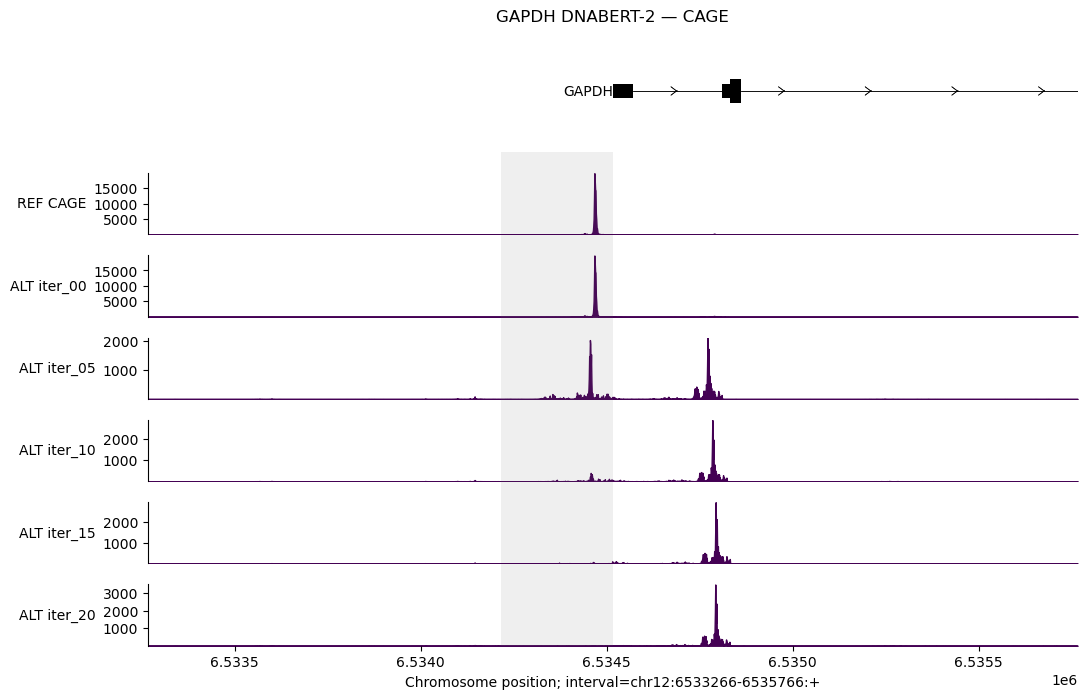

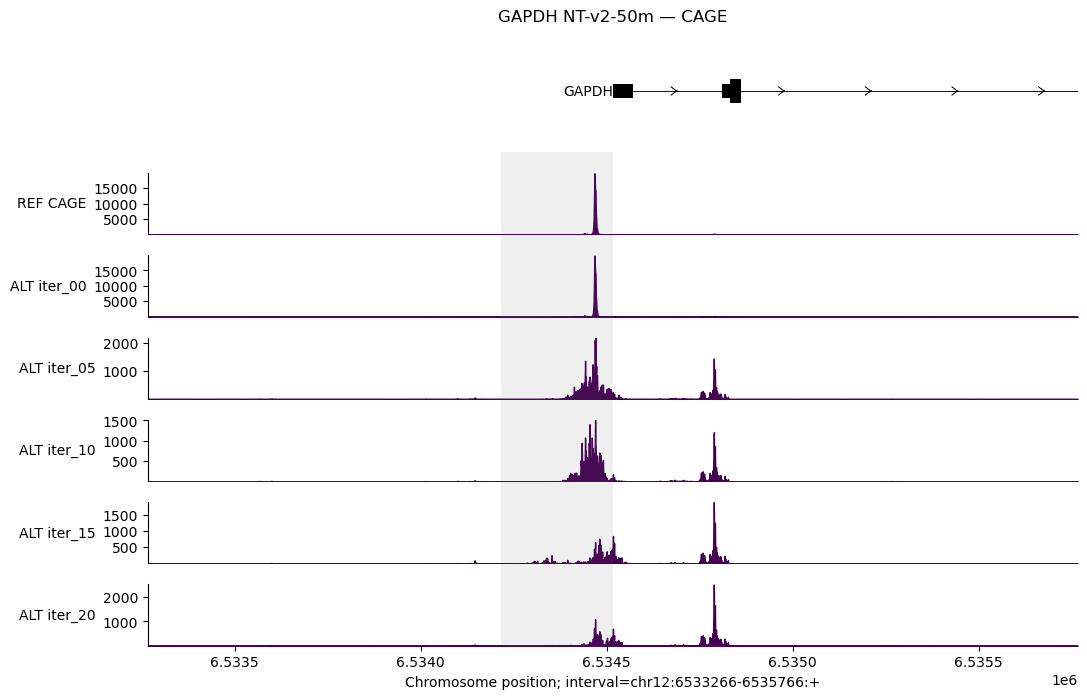

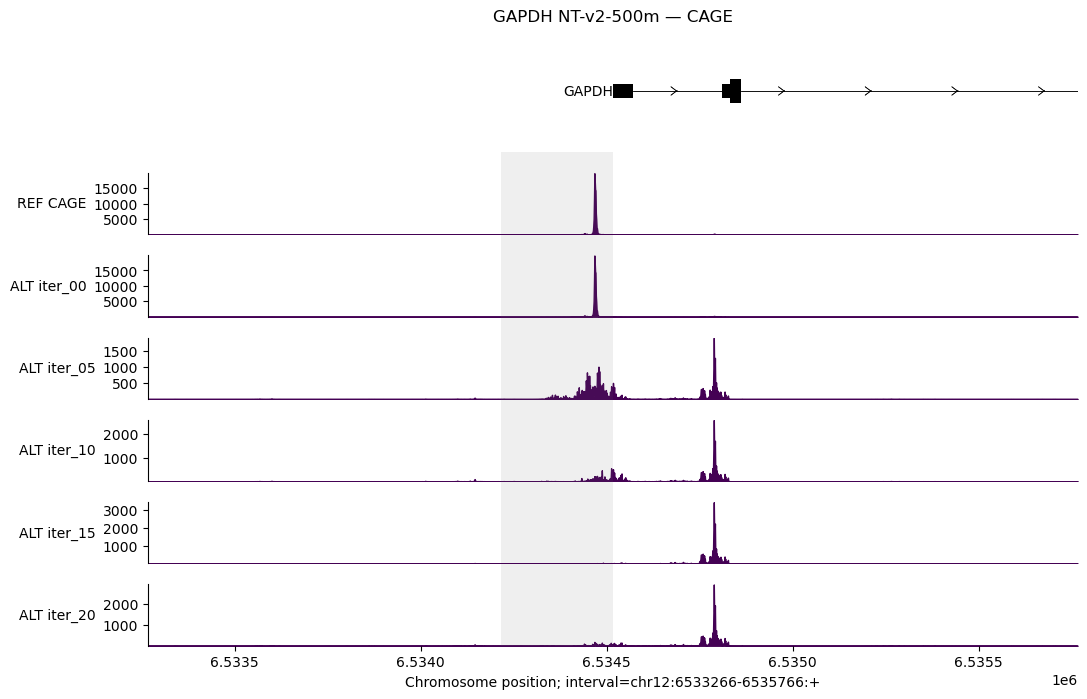

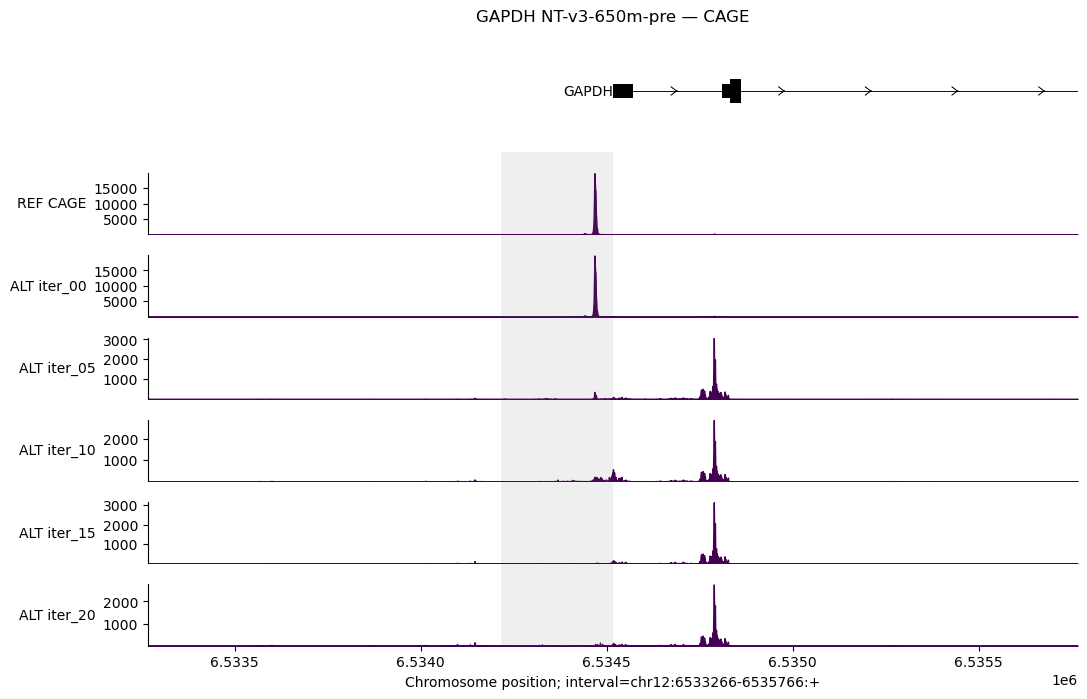

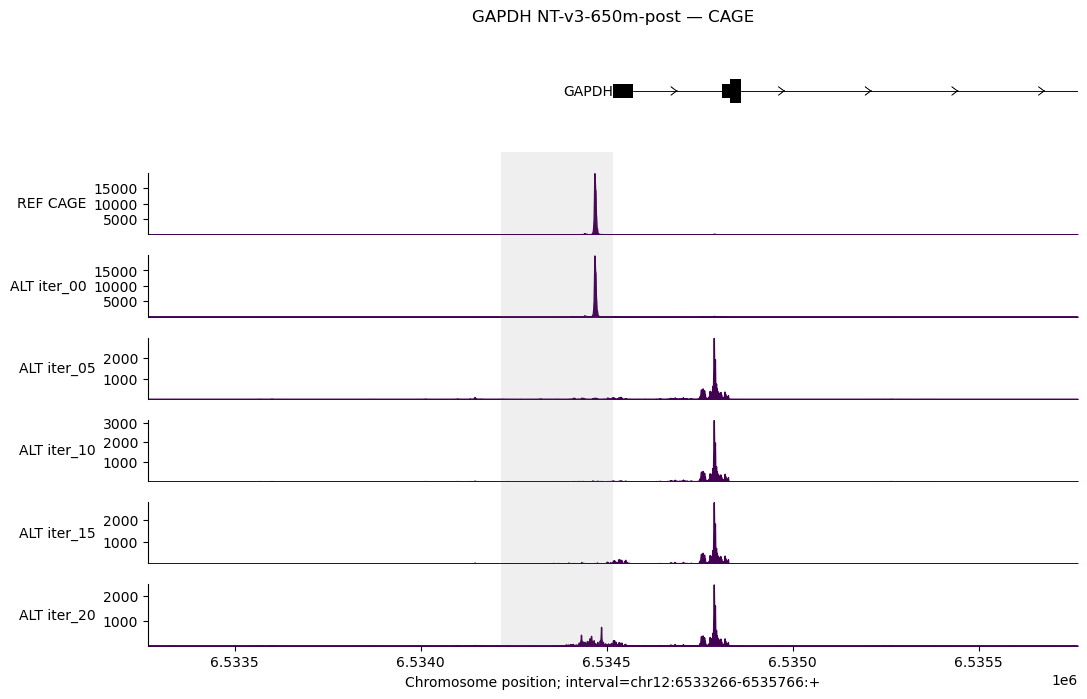

In [8]:
import numpy as np
from alphagenome.visualization import plot_components as pc

# ── Prepare sequences (handle strand orientation) ────────────────
PROMO_LENGTH = len(seqs_by_model[MODEL_LABELS[0]][f'iter_{EVAL_ITERATIONS[0]:02d}'])

oriented_seqs_by_model = {}
for model, iters in seqs_by_model.items():
    oriented_seqs_by_model[model] = {}
    for it, seq in iters.items():
        oriented_seqs_by_model[model][it] = reverse_complement(seq) if strand == '-' else seq

if strand == '-':
    seq_original = normalize_sequence(get_sequence_from_ensembl_region(
        ENSEMBL_SPECIES, chrom, tss, tss + PROMO_LENGTH,
        strand, coord_system_version=ENSEMBL_ASSEMBLY,
    ))
    seq_original = reverse_complement(seq_original)
else:
    seq_original = normalize_sequence(get_sequence_from_ensembl_region(
        ENSEMBL_SPECIES, chrom, tss - PROMO_LENGTH, tss,
        strand, coord_system_version=ENSEMBL_ASSEMBLY,
    ))

print(f'Original promoter: {len(seq_original)} bp')

# ── Predict, visualize, and quantify per model ───────────────────
interval = genome.Interval(chrom, gene_start, gene_end).resize(2**20)
variant_position = gene_start - PROMO_LENGTH if strand == '+' else tss

# Visualization helpers
interval_vis = genome.Interval(chrom, gene_start - 500, gene_start + 500, strand='+')
longest_transcripts = longest_transcript_extractor.extract(interval)
promoter_interval = [
    genome.Interval(chrom, variant_position, variant_position + PROMO_LENGTH, name='Promoter')
]

summary_rows = []

for model in MODEL_LABELS:
    print(f'\n=== {model} ===')

    # 1) Predict variants
    variants = [
        genome.Variant(
            chrom, variant_position, seq_original,
            oriented_seqs_by_model[model][f'iter_{i:02d}'],
        )
        for i in EVAL_ITERATIONS
    ]
    outputs = dna_model.predict_variants(
        intervals=interval,
        variants=variants,
        requested_outputs=requested_outputs,
        ontology_terms=ONTOLOGY_TERMS,
        progress_bar=True,
    )

    # 2) Visualize CAGE tracks
    ref_cage_vis = outputs[0].reference.cage.filter_to_positive_strand()
    alt_cage_vis = [o.alternate.cage.filter_to_positive_strand() for o in outputs]

    components = [
        pc.TranscriptAnnotation(longest_transcripts),
        pc.Tracks(ref_cage_vis, filled=True, ylabel_template='REF CAGE'),
    ]
    for i, alt in zip(EVAL_ITERATIONS, alt_cage_vis):
        components.append(
            pc.Tracks(alt, filled=True, ylabel_template=f'ALT iter_{i:02d}')
        )
    pc.plot(
        components,
        interval=interval_vis.resize(2500),
        annotations=[
            pc.IntervalAnnotation(promoter_interval, colors='dimgrey', alpha=0.1),
        ],
        title=f'{GENE_NAME} {model} — CAGE',
        fig_width=12,
    )

    # 3) Extract quantitative metrics
    ref_cage = outputs[0].reference.cage.filter_to_positive_strand()
    ref_peak = float(np.max(ref_cage.values))
    ref_sum = float(np.sum(ref_cage.values))

    for idx, i in enumerate(EVAL_ITERATIONS):
        alt_cage = outputs[idx].alternate.cage.filter_to_positive_strand()
        alt_peak = float(np.max(alt_cage.values))
        alt_sum = float(np.sum(alt_cage.values))
        summary_rows.append({
            'model': model,
            'iteration': f'iter_{i:02d}',
            'ref_peak': ref_peak,
            'alt_peak': alt_peak,
            'ref_sum': ref_sum,
            'alt_sum': alt_sum,
            'peak_delta': alt_peak - ref_peak,
            'peak_ratio': alt_peak / ref_peak if ref_peak > 0 else float('nan'),
        })

    # 4) Free memory
    del outputs, variants, ref_cage_vis, alt_cage_vis, ref_cage
    gc.collect()
    print(f'  ✓ {model} done, memory released')

# ── Summary table ─────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print(f'\n=== CAGE Signal Summary for {GENE_NAME} ===')
summary_df

In [9]:
# (시각화는 위 통합 셀에서 모델별로 출력됩니다)
# 별도로 다시 시각화하려면 위 셀을 다시 실행하세요.

In [10]:
# (정량 분석은 위 통합 셀에서 summary_df로 생성됩니다)
print(f'=== CAGE Signal Summary for {GENE_NAME} ===')
summary_df

=== CAGE Signal Summary for GAPDH ===


,model,iteration,ref_peak,alt_peak,ref_sum,alt_sum,peak_delta,peak_ratio
0,DNABERT-2,iter_00,19840.0,19840.0,244461.21875,244461.218750,0.0,1.000000
1,DNABERT-2,iter_05,19840.0,6848.0,244461.21875,171512.265625,-12992.0,0.345161
2,DNABERT-2,iter_10,19840.0,6368.0,244461.21875,158588.921875,-13472.0,0.320968
3,DNABERT-2,iter_15,19840.0,6688.0,244461.21875,155630.062500,-13152.0,0.337097
4,DNABERT-2,iter_20,19840.0,6368.0,244461.21875,158363.359375,-13472.0,0.320968
5,NT-v2-50m,iter_00,19840.0,19840.0,244461.21875,244461.218750,0.0,1.000000
6,NT-v2-50m,iter_05,19840.0,6688.0,244461.21875,187562.171875,-13152.0,0.337097
7,NT-v2-50m,iter_10,19840.0,6688.0,244461.21875,176722.109375,-13152.0,0.337097
8,NT-v2-50m,iter_15,19840.0,6592.0,244461.21875,171220.781250,-13248.0,0.332258
9,NT-v2-50m,iter_20,19840.0,6688.0,244461.21875,171717.437500,-13152.0,0.337097


---
## Part 5: All Ontology Terms Scan
생성된 서열이 다른 cell type에서 더 높은 활성을 보일 가능성을 확인합니다.

`ontology_terms=None`으로 설정하면 모든 가능한 cell ontology에 대해 예측합니다.

**API 비용 절감을 위해 마지막 iteration, 하나의 모델에 대해서만 수행합니다.**

In [11]:
# ── Settings for ontology scan ───────────────────────────────────
SCAN_MODELS = MODEL_LABELS                       # 모든 모델 스캔 (수정 가능)
SCAN_ITERATION = 5                               # iteration 5 사용

print(f'Scanning: models={SCAN_MODELS}, iteration=iter_{SCAN_ITERATION:02d}')

Scanning: models=['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m', 'NT-v3-650m-pre', 'NT-v3-650m-post'], iteration=iter_05


In [12]:
scan_requested = {dna_client.OutputType.CAGE}

# Promoter 영역 + padding으로 분석 범위 제한
promoter_analysis_interval = genome.Interval(
    chrom,
    variant_position - PROMOTER_PADDING,
    variant_position + PROMO_LENGTH + PROMOTER_PADDING,
)
print(f'Analysis interval: {promoter_analysis_interval}')

all_scan_dfs = []

for scan_model in SCAN_MODELS:
    scan_seq = oriented_seqs_by_model[scan_model][f'iter_{SCAN_ITERATION:02d}']
    scan_variant = genome.Variant(
        chrom, variant_position, seq_original, scan_seq,
    )

    print(f'Predicting {scan_model} with ontology_terms=None (all cell types)...')
    scan_output = dna_model.predict_variant(
        interval=interval,
        variant=scan_variant,
        requested_outputs=scan_requested,
        ontology_terms=None,
    )

    # ── Extract metrics (promoter region only) ───────────────────
    alt_cage = scan_output.alternate.cage.filter_to_positive_strand()
    ref_cage = scan_output.reference.cage.filter_to_positive_strand()
    alt_cage = alt_cage.slice_by_interval(promoter_analysis_interval)
    ref_cage = ref_cage.slice_by_interval(promoter_analysis_interval)
    metadata = alt_cage.metadata

    rows = []
    for track_idx in range(alt_cage.num_tracks):
        alt_peak = float(np.max(alt_cage.values[:, track_idx]))
        ref_peak = float(np.max(ref_cage.values[:, track_idx]))
        track_meta = metadata.iloc[track_idx]
        rows.append({
            'model': scan_model,
            'track_name': track_meta.get('name', f'track_{track_idx}'),
            'biosample_name': track_meta.get('biosample_name', 'unknown'),
            'alt_peak': alt_peak,
            'ref_peak': ref_peak,
            'delta': alt_peak - ref_peak,
            'ratio': alt_peak / ref_peak if ref_peak > 0 else float('nan'),
        })

    scan_df = pd.DataFrame(rows)
    all_scan_dfs.append(scan_df)

    # ── Display per-model results ────────────────────────────────
    top_by_peak = scan_df.sort_values('alt_peak', ascending=False).head(20)
    top_by_ratio = scan_df.sort_values('ratio', ascending=False).head(20)

    print(f'\n--- {scan_model} (iter_{SCAN_ITERATION:02d}): Top 20 by ALT peak ---')
    display(top_by_peak)
    print(f'\n--- {scan_model} (iter_{SCAN_ITERATION:02d}): Top 20 by ratio (ALT/REF) ---')
    display(top_by_ratio)

    # ── Free memory ──────────────────────────────────────────────
    del scan_output, alt_cage, ref_cage, scan_variant
    gc.collect()
    print(f'  ✓ {scan_model} done, memory released\n')

# Combine all results
all_scan_df = pd.concat(all_scan_dfs, ignore_index=True)
print(f'Total scan results: {len(all_scan_df)} rows across {len(SCAN_MODELS)} models')

Analysis interval: chr12:6533716-6535016:.
Predicting DNABERT-2 with ontology_terms=None (all cell types)...

--- DNABERT-2 (iter_05): Top 20 by ALT peak ---


,model,track_name,biosample_name,alt_peak,ref_peak,delta,ratio
14,DNABERT-2,LQhCAGE UBERON:0012168,umbilical cord blood,6016.0,34048.0,-28032.0,0.176692
6,DNABERT-2,LQhCAGE CL:0000840,immature conventional dendritic cell,5184.0,29824.0,-24640.0,0.173820
251,DNABERT-2,hCAGE UBERON:0002369,adrenal gland,5120.0,26880.0,-21760.0,0.190476
108,DNABERT-2,hCAGE CL:0002581,perirenal preadipocyte,4544.0,30848.0,-26304.0,0.147303
9,DNABERT-2,LQhCAGE CL:0002166,epithelial cell of Malassez,3920.0,27392.0,-23472.0,0.143107
0,DNABERT-2,LQhCAGE CL:0000077,mesothelial cell,3760.0,25728.0,-21968.0,0.146144
24,DNABERT-2,hCAGE CL:0000216,Sertoli cell,3616.0,25856.0,-22240.0,0.139851
122,DNABERT-2,hCAGE CL:0002597,smooth muscle cell of bladder,3536.0,25088.0,-21552.0,0.140944
85,DNABERT-2,hCAGE CL:0002554,fibroblast of lymphatic vessel,3408.0,27008.0,-23600.0,0.126185
86,DNABERT-2,hCAGE CL:0002555,fibroblast of mammary gland,3360.0,26368.0,-23008.0,0.127427



--- DNABERT-2 (iter_05): Top 20 by ratio (ALT/REF) ---


,model,track_name,biosample_name,alt_peak,ref_peak,delta,ratio
251,DNABERT-2,hCAGE UBERON:0002369,adrenal gland,5120.0,26880.0,-21760.0,0.190476
14,DNABERT-2,LQhCAGE UBERON:0012168,umbilical cord blood,6016.0,34048.0,-28032.0,0.176692
6,DNABERT-2,LQhCAGE CL:0000840,immature conventional dendritic cell,5184.0,29824.0,-24640.0,0.173820
209,DNABERT-2,hCAGE UBERON:0001831,parotid gland,1336.0,7840.0,-6504.0,0.170408
190,DNABERT-2,hCAGE UBERON:0001044,saliva-secreting gland,1072.0,6400.0,-5328.0,0.167500
207,DNABERT-2,hCAGE UBERON:0001736,submandibular gland,964.0,6080.0,-5116.0,0.158553
255,DNABERT-2,hCAGE UBERON:0002448,fungiform papilla,138.0,908.0,-770.0,0.151982
204,DNABERT-2,hCAGE UBERON:0001637,artery,2432.0,16128.0,-13696.0,0.150794
11,DNABERT-2,LQhCAGE CL:0002193,myelocyte,2480.0,16640.0,-14160.0,0.149038
108,DNABERT-2,hCAGE CL:0002581,perirenal preadipocyte,4544.0,30848.0,-26304.0,0.147303


  ✓ DNABERT-2 done, memory released

Predicting NT-v2-50m with ontology_terms=None (all cell types)...

--- NT-v2-50m (iter_05): Top 20 by ALT peak ---


...

  ✓ NT-v3-650m-pre done, memory released

Predicting NT-v3-650m-post with ontology_terms=None (all cell types)...

--- NT-v3-650m-post (iter_05): Top 20 by ALT peak ---


,model,track_name,biosample_name,alt_peak,ref_peak,delta,ratio
14,NT-v3-650m-post,LQhCAGE UBERON:0012168,umbilical cord blood,7936.0,34048.0,-26112.0,0.233083
6,NT-v3-650m-post,LQhCAGE CL:0000840,immature conventional dendritic cell,6784.0,29824.0,-23040.0,0.227468
251,NT-v3-650m-post,hCAGE UBERON:0002369,adrenal gland,6336.0,26880.0,-20544.0,0.235714
108,NT-v3-650m-post,hCAGE CL:0002581,perirenal preadipocyte,5984.0,30848.0,-24864.0,0.193983
9,NT-v3-650m-post,LQhCAGE CL:0002166,epithelial cell of Malassez,5376.0,27392.0,-22016.0,0.196262
0,NT-v3-650m-post,LQhCAGE CL:0000077,mesothelial cell,4992.0,25728.0,-20736.0,0.194030
24,NT-v3-650m-post,hCAGE CL:0000216,Sertoli cell,4768.0,25856.0,-21088.0,0.184406
122,NT-v3-650m-post,hCAGE CL:0002597,smooth muscle cell of bladder,4640.0,25088.0,-20448.0,0.184949
86,NT-v3-650m-post,hCAGE CL:0002555,fibroblast of mammary gland,4608.0,26368.0,-21760.0,0.174757
100,NT-v3-650m-post,hCAGE CL:0002572,vertebral mesenchymal stem cell,4544.0,26240.0,-21696.0,0.173171



--- NT-v3-650m-post (iter_05): Top 20 by ratio (ALT/REF) ---


,model,track_name,biosample_name,alt_peak,ref_peak,delta,ratio
251,NT-v3-650m-post,hCAGE UBERON:0002369,adrenal gland,6336.0,26880.0,-20544.0,0.235714
14,NT-v3-650m-post,LQhCAGE UBERON:0012168,umbilical cord blood,7936.0,34048.0,-26112.0,0.233083
6,NT-v3-650m-post,LQhCAGE CL:0000840,immature conventional dendritic cell,6784.0,29824.0,-23040.0,0.227468
209,NT-v3-650m-post,hCAGE UBERON:0001831,parotid gland,1752.0,7840.0,-6088.0,0.223469
190,NT-v3-650m-post,hCAGE UBERON:0001044,saliva-secreting gland,1384.0,6400.0,-5016.0,0.216250
11,NT-v3-650m-post,LQhCAGE CL:0002193,myelocyte,3312.0,16640.0,-13328.0,0.199038
9,NT-v3-650m-post,LQhCAGE CL:0002166,epithelial cell of Malassez,5376.0,27392.0,-22016.0,0.196262
0,NT-v3-650m-post,LQhCAGE CL:0000077,mesothelial cell,4992.0,25728.0,-20736.0,0.194030
108,NT-v3-650m-post,hCAGE CL:0002581,perirenal preadipocyte,5984.0,30848.0,-24864.0,0.193983
207,NT-v3-650m-post,hCAGE UBERON:0001736,submandibular gland,1160.0,6080.0,-4920.0,0.190789


  ✓ NT-v3-650m-post done, memory released

Total scan results: 1365 rows across 5 models


In [ ]:
# ── Cross-model summary: top cell types by average ratio ─────────
avg_ratio = (
    all_scan_df
    .groupby('biosample_name')['ratio']
    .mean()
    .sort_values(ascending=False)
)
print(f'=== Top 20 cell types by average ALT/REF ratio across all models ===')
avg_ratio.head(20)

=== Top 20 cell types by average ALT/REF ratio across all models ===


biosample_name
adrenal gland                           0.200952
umbilical cord blood                    0.196805
parotid gland                           0.191429
saliva-secreting gland                  0.183625
myelocyte                               0.168846
submandibular gland                     0.168421
perirenal preadipocyte                  0.166805
pancreas                                0.160692
smooth muscle cell of bladder           0.159694
Sertoli cell                            0.158540
SK-N-MC                                 0.157558
fungiform papilla                       0.157269
heart left ventricle                    0.156213
umbilical cord                          0.156015
artery                                  0.155258
left cardiac atrium                     0.154833
immature conventional dendritic cell    0.154629
vitreous humor                          0.153667
perirenal adipocyte cell                0.150397
rectum                                  0.149733
Name:

: 